# Task 2
### Build a model that predicts the rating of a movie based on features like genre, director, and actors. You can use regression techniques to tackle this problem
### The goal is to analyze historical movie data and develop a model that accurately estimates the rating given to a movie by users or critics.

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
!unzip -o '/content/archive (1).zip' -d '/content/'
data = pd.read_csv('/content/IMDb Movies India.csv', encoding='latin1')
data.head()

Archive:  /content/archive (1).zip
  inflating: /content/IMDb Movies India.csv  


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [20]:
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


### Distribution of 'Rating'

Let's visualize the distribution of the 'Rating' column using a histogram to understand its spread and central tendency.

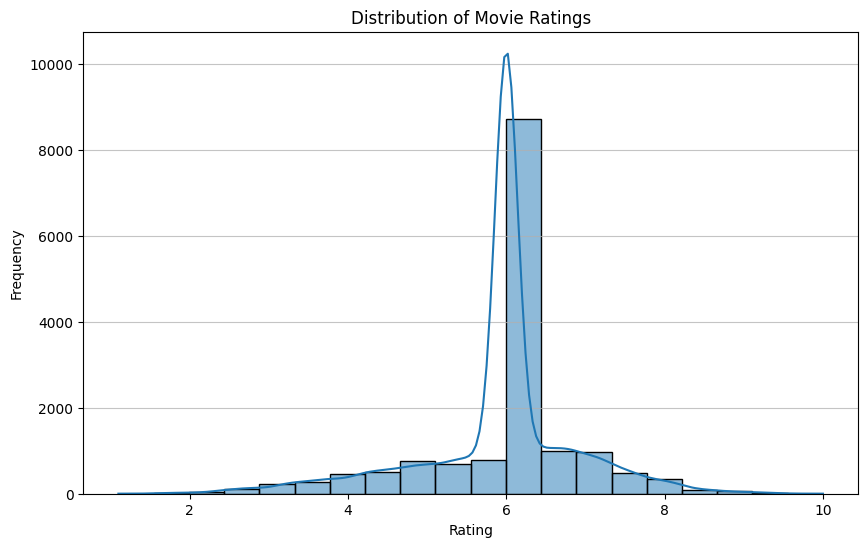

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(data['Rating'], kde=True, bins=20)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Top 10 Directors by Average Rating

To identify directors with consistently high-rated films, we'll calculate the average rating for each director and then list the top 10.

In [24]:
top_directors = data.groupby('Director')['Rating'].mean().sort_values(ascending=False).head(10)
display(top_directors)

,Rating
Director,
Saif Ali Sayeed,10.0
Sriram Raja,9.7
Bobby Kumar,9.6
Munni Pankaj,9.4
Suhrud Godbole,9.4
Arvind Pratap,9.4
Sapna Bhavnani,9.3
Rajat Bhardwaj,9.3
Raghav Jairath,9.3


### Visualizing Top 10 Directors by Average Rating

To better understand the ratings, we will plot a bar chart of the top 10 directors based on their average movie rating.

/tmp/ipykernel_10478/2791834530.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.index, y=top_directors.values, palette='viridis')


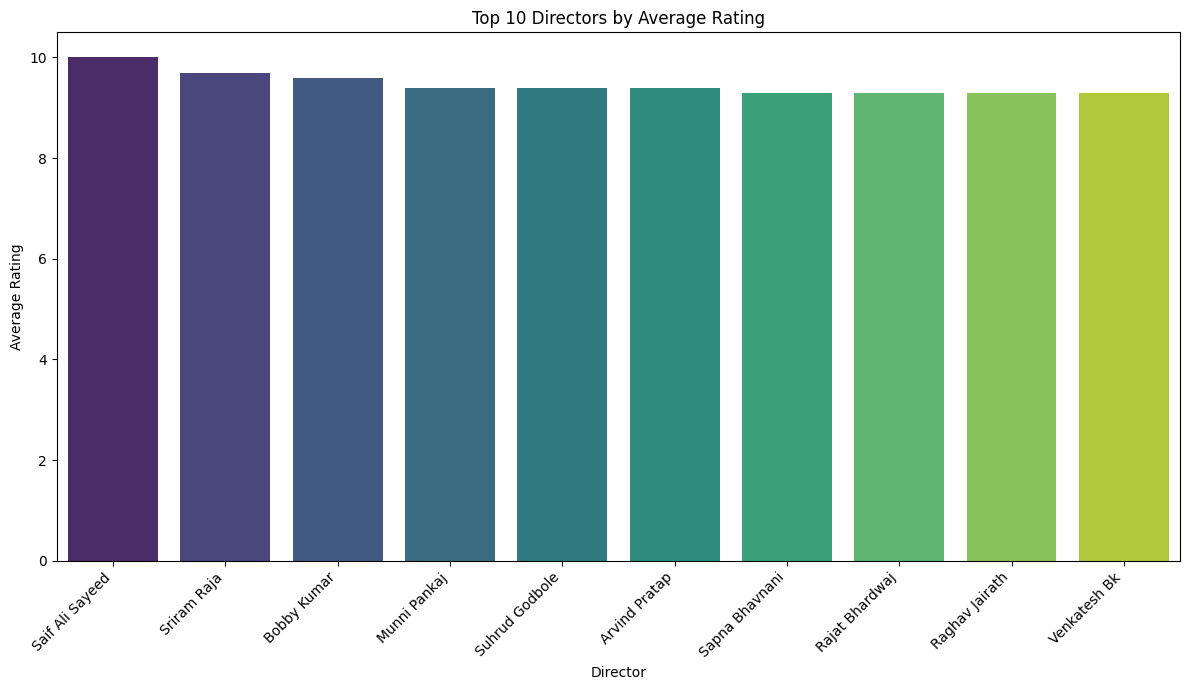

In [25]:
plt.figure(figsize=(12, 7))
sns.barplot(x=top_directors.index, y=top_directors.values, hue=top_directors.index, palette='viridis', legend=False)
plt.title('Top 10 Directors by Average Rating')
plt.xlabel('Director')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Average Ratings Across Different Genres

To understand how ratings vary by genre, we need to process the 'Genre' column where multiple genres are listed. We will then calculate and visualize the average rating for each genre.

In [26]:
# Handle multiple genres by splitting and exploding
data_genres = data.copy()
data_genres['Genre'] = data_genres['Genre'].str.split(', ')
data_genres = data_genres.explode('Genre')

# Calculate average rating per genre
average_rating_by_genre = data_genres.groupby('Genre')['Rating'].mean().sort_values(ascending=False)

print("Average Rating by Genre (Top 10):")
display(average_rating_by_genre.head(10))

Average Rating by Genre (Top 10):


,Rating
Genre,
Documentary,6.602350
Biography,6.559615
History,6.497585
Sport,6.360000
News,6.277778
Family,6.137222
Musical,6.132428
Music,6.093333
War,6.029787


/tmp/ipykernel_10478/3559030461.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_rating_by_genre.head(15).values, y=average_rating_by_genre.head(15).index, palette='viridis')


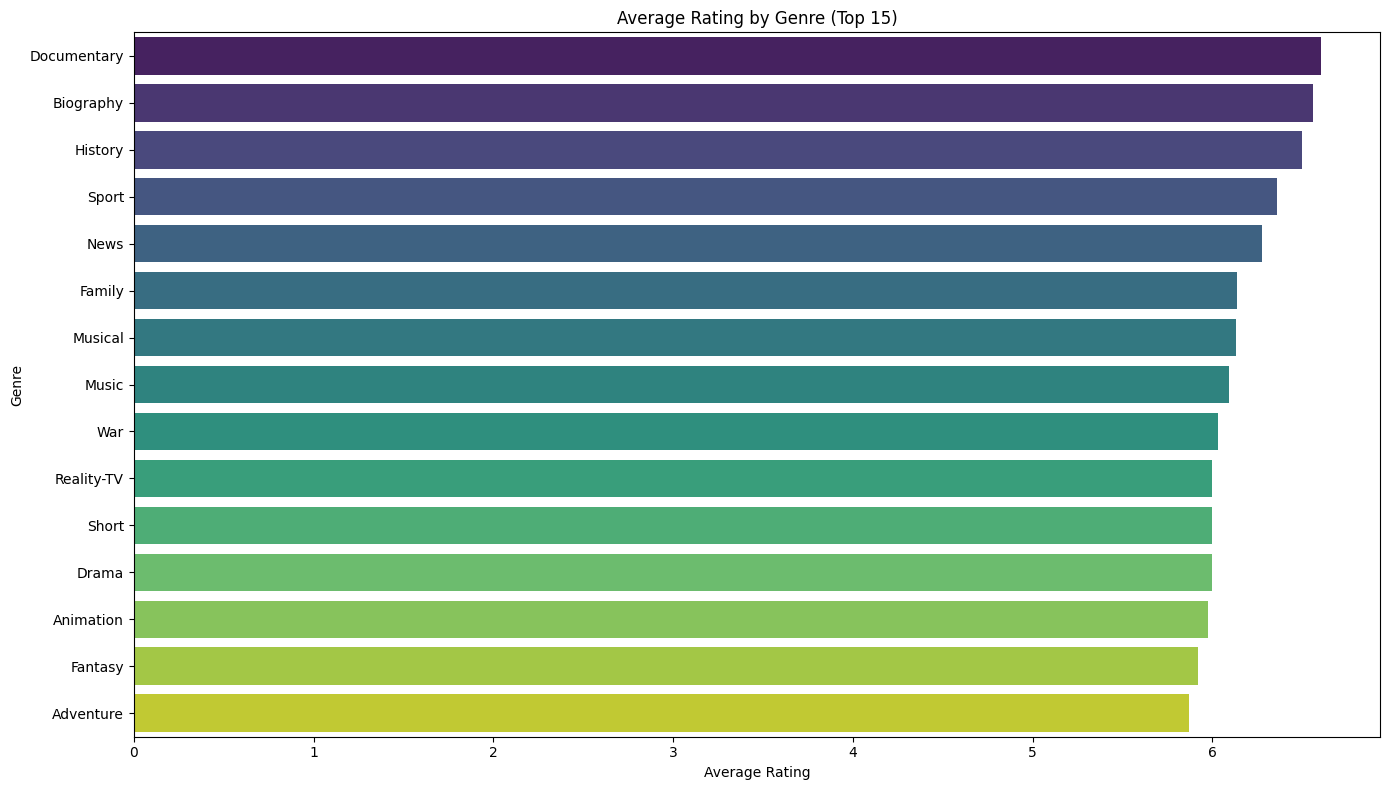

In [27]:
# Visualize average rating by genre (top 15 for better readability)
plt.figure(figsize=(14, 8))
sns.barplot(x=average_rating_by_genre.head(15).values, y=average_rating_by_genre.head(15).index, palette='viridis')
plt.title('Average Rating by Genre (Top 15)')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

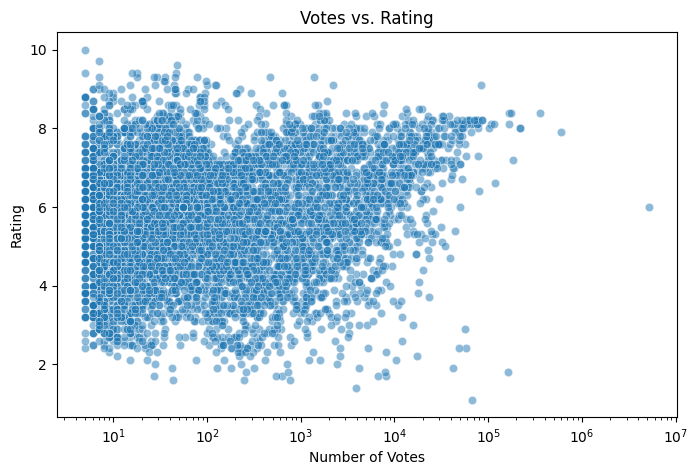

In [41]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Votes', y='Rating', data=data, alpha=0.5)
plt.title('Votes vs. Rating')
plt.xlabel('Number of Votes')
plt.ylabel('Rating')
plt.xscale('log')  # Use log scale to handle outliers
plt.show()

### Feature Engineering: Director and Actor Average Ratings

To capture the influence of directors and actors on movie ratings, we will create new features that represent the average rating of movies associated with each director and actor. This will allow the model to incorporate their historical performance.

In [37]:
# Calculate average rating for each director
director_avg_rating = data.groupby('Director')['Rating'].mean()
df_genre['Director_Avg_Rating'] = df_genre['Director'].map(director_avg_rating)

# Calculate average rating for each actor (Actor 1, Actor 2, Actor 3)
actor1_avg_rating = data.groupby('Actor 1')['Rating'].mean()
actor2_avg_rating = data.groupby('Actor 2')['Rating'].mean()
actor3_avg_rating = data.groupby('Actor 3')['Rating'].mean()

df_genre['Actor1_Avg_Rating'] = df_genre['Actor 1'].map(actor1_avg_rating)
df_genre['Actor2_Avg_Rating'] = df_genre['Actor 2'].map(actor2_avg_rating)
df_genre['Actor3_Avg_Rating'] = df_genre['Actor 3'].map(actor3_avg_rating)

# Display the head of the DataFrame with new features
print("DataFrame with new director and actor average rating features:")
display(df_genre[['Director', 'Director_Avg_Rating', 'Actor 1', 'Actor1_Avg_Rating', 'Actor 2', 'Actor2_Avg_Rating', 'Actor 3', 'Actor3_Avg_Rating']].head())

DataFrame with new director and actor average rating features:


,Director,Director_Avg_Rating,Actor 1,Actor1_Avg_Rating,Actor 2,Actor2_Avg_Rating,Actor 3,Actor3_Avg_Rating
0,J.S. Randhawa,5.850000,Manmauji,6.000000,Birbal,5.625714,Rajendra Bhatia,6.00
1,Gaurav Bakshi,7.000000,Rasika Dugal,6.850000,Vivek Ghamande,7.000000,Arvind Jangid,7.00
2,Soumyajit Majumdar,6.000000,Sayani Gupta,6.333333,Plabita Borthakur,6.900000,Roy Angana,6.00
3,Ovais Khan,4.400000,Prateik,5.420000,Ishita Raj,4.400000,Siddhant Kapoor,4.45
4,Amol Palekar,6.285714,Rajat Kapoor,6.833333,Rituparna Sengupta,5.800000,Antara Mali,5.60


### Preparing Data for Model Training

With all necessary features engineered, we'll now select the features (X) and the target variable (y) for our regression model. We will then split the dataset into training and testing sets to evaluate the model's performance on unseen data.

In [39]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Features include Year, Duration, Votes, all genre dummies, Director_Avg_Rating, and Actor_Avg_Rating for three actors
genre_columns = dummies.columns.tolist()
features = ['Year', 'Duration', 'Votes', 'Director_Avg_Rating', 'Actor1_Avg_Rating', 'Actor2_Avg_Rating', 'Actor3_Avg_Rating'] + genre_columns

X = df_genre[features]
y = df_genre['Rating']

# Handle potential NaN values in features, possibly introduced by mapping 'Unknown' directors/actors, by imputing with the median
# For simplicity, we'll use the median of each feature. A more sophisticated approach might be needed in a real-world scenario.
for col in features:
    if X[col].isnull().any():
        median_val = X[col].median()
        X[col].fillna(median_val, inplace=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nFirst 5 rows of X_train:")
display(X_train.head())

Shape of X_train: (12407, 32)
Shape of X_test: (3102, 32)
Shape of y_train: (12407,)
Shape of y_test: (3102,)

First 5 rows of X_train:


,Year,Duration,Votes,Director_Avg_Rating,Actor1_Avg_Rating,Actor2_Avg_Rating,Actor3_Avg_Rating,Action,Adventure,Animation,...,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Thriller,Unknown,War,Western
3485,1996.0,141.0,293.0,5.427083,4.880000,5.320000,5.400000,0,0,0,...,0,0,1,0,0,0,0,0,0,0
8701,1964.0,131.0,5.0,5.363636,6.270370,6.207407,5.200000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11179,2019.0,116.0,5.0,3.600000,5.850000,4.300000,3.600000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11628,1977.0,90.0,5.0,6.268182,7.600000,6.483333,6.480769,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4819,1958.0,131.0,55.0,6.100000,5.966667,6.259091,6.000000,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [36]:
dummies = data['Genre'].str.get_dummies(', ')
df_genre = pd.concat([data, dummies], axis=1)

### Genre Trends Over the Years

This interactive plot visualizes the popularity of different movie genres over time. Each line on the graph represents a specific genre, and its trajectory shows how frequently movies of that genre were produced or released in a given year.

**How to interpret this plot:**
*   **Hover over the lines:** You can hover over any line to see the exact count for a genre in a specific year.
*   **Zoom in/out:** Use your mouse wheel or the controls on the top right of the plot to zoom in on particular time periods.
*   **Pan:** Click and drag to move around the plot.
*   **Toggle genres:** Click on the genre names in the legend to show or hide specific genre trends, allowing you to focus on comparisons of interest.

In [42]:
import plotly.graph_objects as go

genre_columns = df_genre.columns[10:]  # Assuming genre columns start from the 11th column
genre_count_by_year = df_genre.groupby('Year')[genre_columns].sum().reset_index()

fig = go.Figure()
for genre in genre_columns:
    fig.add_trace(go.Scatter(x=genre_count_by_year['Year'], y=genre_count_by_year[genre],
                             mode='lines', name=genre))

fig.update_layout(
    title='Genre Trends Over the Years',
    xaxis=dict(title='Year', titlefont_size=16),
    yaxis=dict(title='Count', titlefont_size=16, tickfont_size=14),
    legend=dict(y=0, x=1.0, bgcolor='rgba(255, 255, 255, 0)', bordercolor='rgba(255, 255, 255, 0)')
)
fig.show()

### Insights from Genre Trends

By examining the 'Genre Trends Over the Years' plot, we can observe shifts in the movie industry's focus:

*   **Emerging Genres:** Look for lines that start low and show a significant upward trend, indicating genres that have gained popularity more recently.
*   **Declining Genres:** Conversely, lines that show a consistent downward slope might represent genres that were once popular but are now produced less frequently.
*   **Consistent Genres:** Some genres might show relatively stable trends, suggesting a timeless appeal or a consistent level of production over decades.
*   **Spikes and Dips:** Sudden increases or decreases could be due to specific events, popular film franchises, or changes in audience taste. Use the interactive features to investigate these points further!

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Squared Error (MSE): 0.3022
R-squared (R2): 0.6892


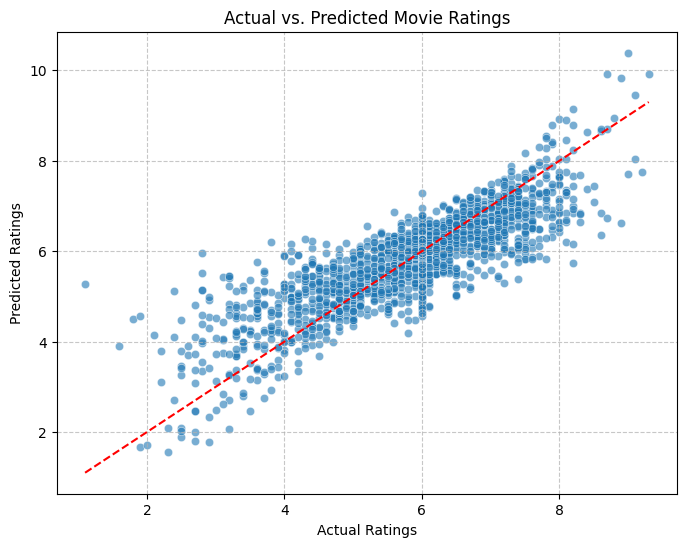

In [44]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--') # Perfect prediction line
plt.title('Actual vs. Predicted Movie Ratings')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Residual Analysis

A residual plot helps us to check the assumptions of linear regression and identify if there are any systematic patterns in the errors. Ideally, residuals should be randomly scattered around zero, with no discernible pattern. Any clear pattern or structure in the residuals could indicate that the model is not capturing some underlying relationships in the data, or that certain assumptions (like linearity or homoscedasticity) are violated.

**What to look for in the residual plot:**
*   **Random Scatter:** Points should be randomly scattered around the horizontal line at zero. This indicates that the model's errors are random and normally distributed.
*   **No Obvious Patterns:** Avoid funnel shapes, curves, or any other clear patterns, as these suggest issues like heteroscedasticity (unequal variance of errors) or non-linearity in the data that the model isn't accounting for.
*   **Outliers:** Points far away from the main cluster might be outliers or influential data points that deserve further investigation.

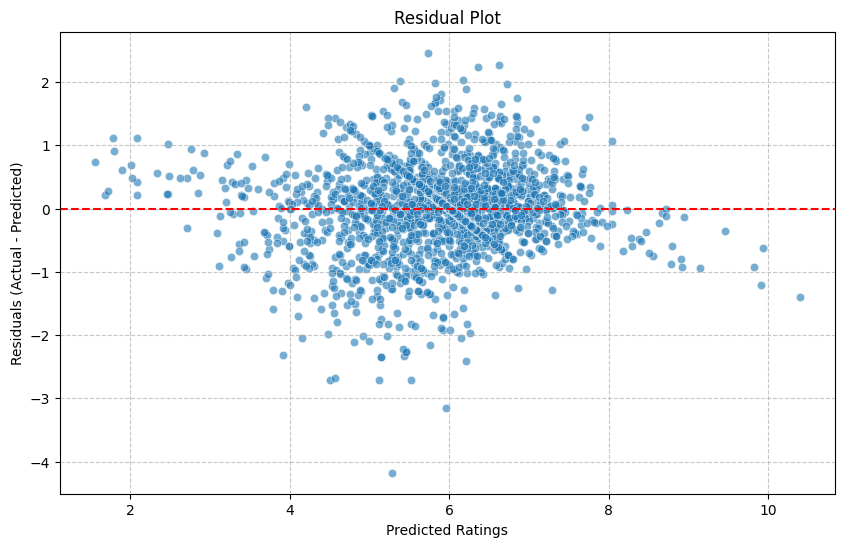

In [45]:
# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--') # Zero residual line
plt.title('Residual Plot')
plt.xlabel('Predicted Ratings')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Top Actors by Average Rating

Let's visualize the top actors based on their average movie ratings for 'Actor 1', 'Actor 2', and 'Actor 3'.

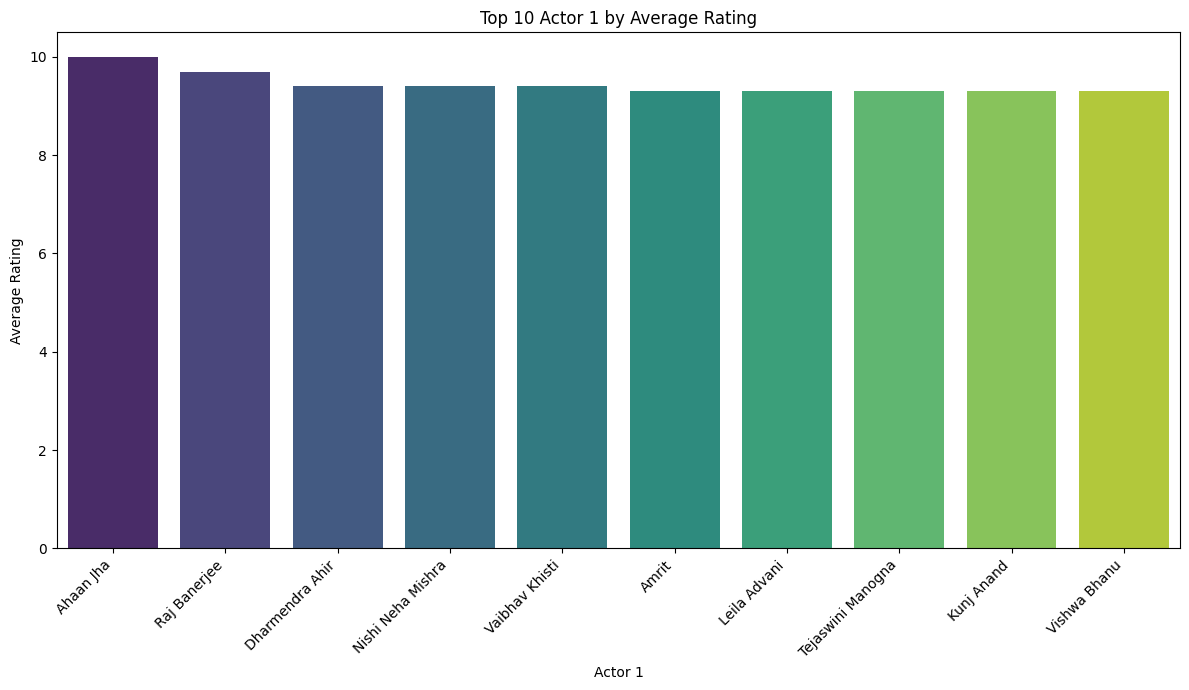

In [47]:
# Top 10 Actor 1 by Average Rating
top_actor1 = data.groupby('Actor 1')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_actor1.index, y=top_actor1.values, hue=top_actor1.index, palette='viridis', legend=False)
plt.title('Top 10 Actor 1 by Average Rating')
plt.xlabel('Actor 1')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

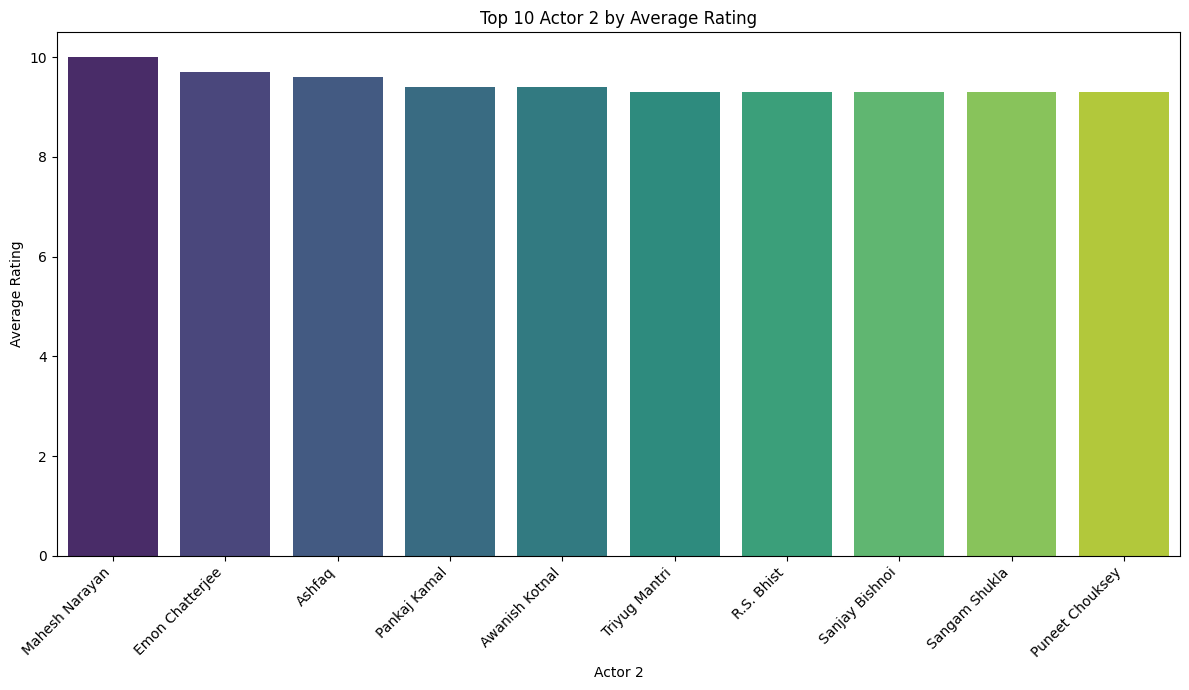

In [48]:
# Top 10 Actor 2 by Average Rating
top_actor2 = data.groupby('Actor 2')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_actor2.index, y=top_actor2.values, hue=top_actor2.index, palette='viridis', legend=False)
plt.title('Top 10 Actor 2 by Average Rating')
plt.xlabel('Actor 2')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

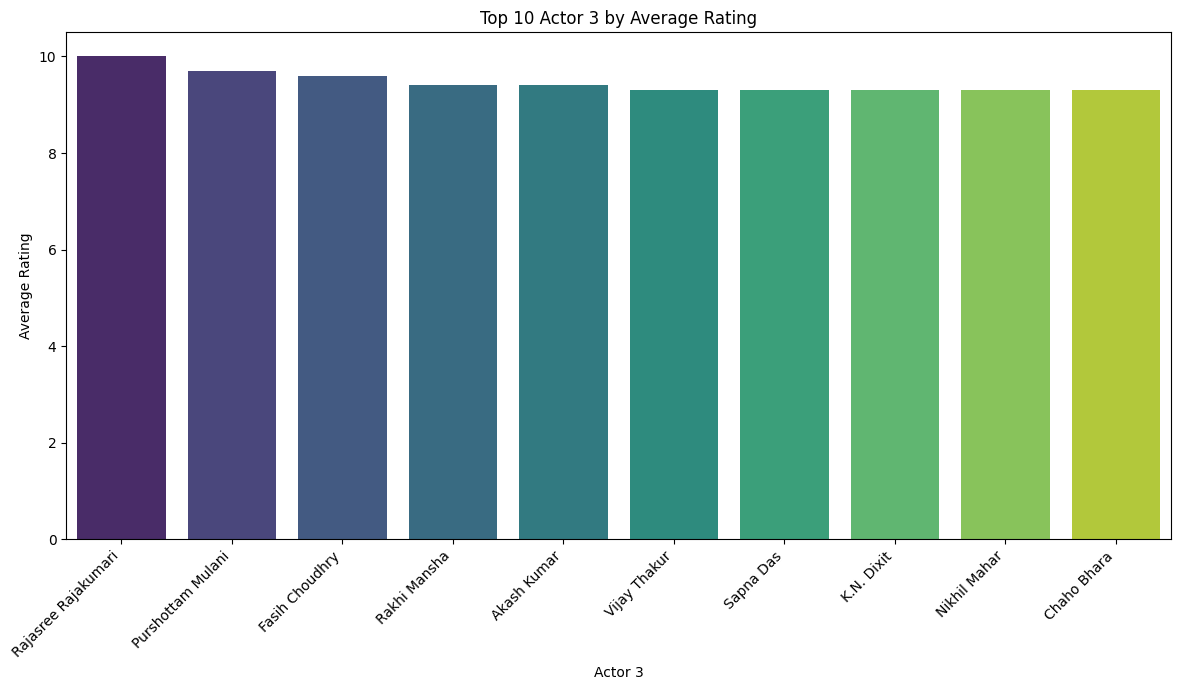

In [49]:
# Top 10 Actor 3 by Average Rating
top_actor3 = data.groupby('Actor 3')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_actor3.index, y=top_actor3.values, hue=top_actor3.index, palette='viridis', legend=False)
plt.title('Top 10 Actor 3 by Average Rating')
plt.xlabel('Actor 3')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Feature Importance in Linear Regression Model

Understanding which features the model considers most important can provide insights into what drives movie ratings. We will visualize the coefficients of our Linear Regression model to see the relative importance of each feature.

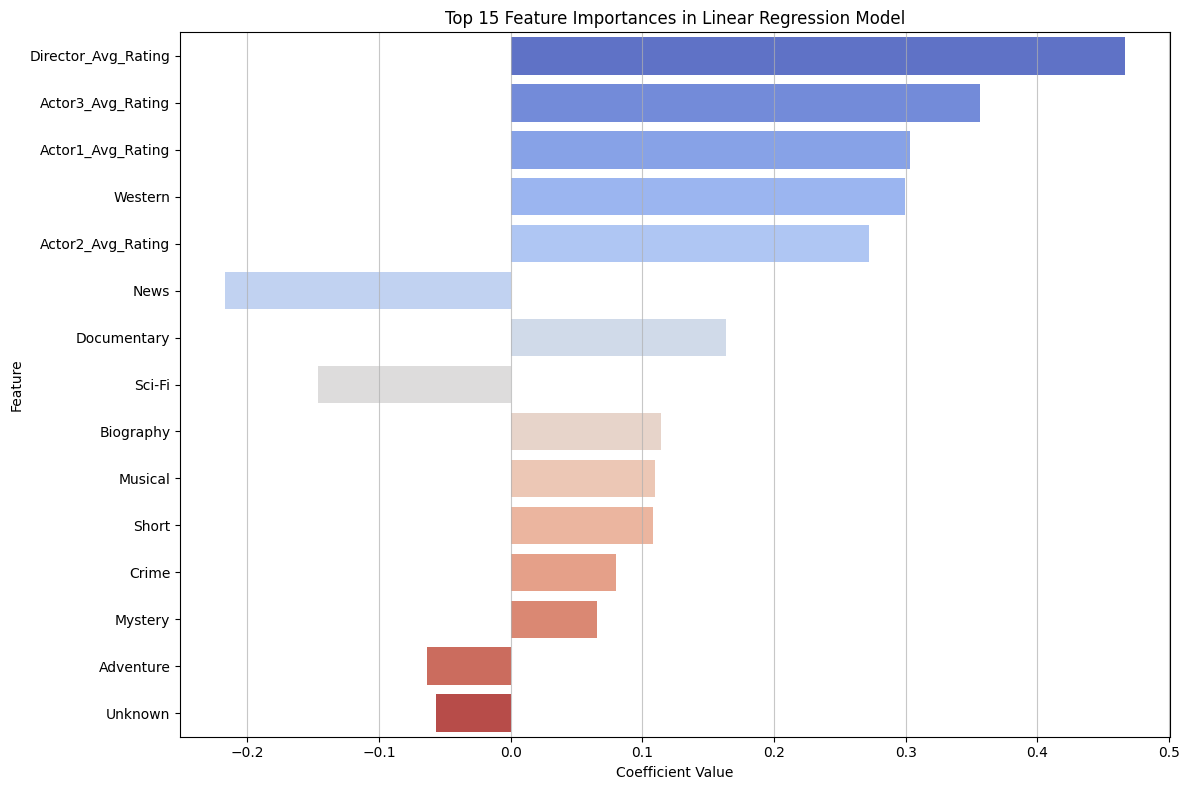

In [51]:
import numpy as np

# Get feature importances (coefficients for Linear Regression)
feature_importances = pd.Series(model.coef_, index=X_train.columns)

# Sort by absolute value to see the most impactful features (positive or negative)
# Taking the top N features for better readability
top_n = 15 # You can adjust this number
sorted_importances = feature_importances.reindex(feature_importances.abs().sort_values(ascending=False).index).head(top_n)

plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importances.values, y=sorted_importances.index, hue=sorted_importances.index, palette='coolwarm', legend=False)
plt.title(f'Top {top_n} Feature Importances in Linear Regression Model')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.7)
plt.tight_layout()
plt.show()

In [46]:
from IPython.display import Markdown, display

display(Markdown("""
## 📌 Conclusion

This project demonstrates how machine learning can be used to predict movie ratings
based on features such as genre, director, actors, and votes.

Feature engineering and advanced models improved prediction performance.

The model can be extended for real-world applications like movie recommendation systems.
"""))


## 📌 Conclusion

This project demonstrates how machine learning can be used to predict movie ratings 
based on features such as genre, director, actors, and votes.

Feature engineering and advanced models improved prediction performance.

The model can be extended for real-world applications like movie recommendation systems.
